In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt


In [13]:
df=pd.read_csv("iris.data.csv",header=None)
df

,0,1,2,3,4
0,5.1,3.5,1.4,0.2,Iris-setosa
1,4.9,3.0,1.4,0.2,Iris-setosa
2,4.7,3.2,1.3,0.2,Iris-setosa
3,4.6,3.1,1.5,0.2,Iris-setosa
4,5.0,3.6,1.4,0.2,Iris-setosa
...,...,...,...,...,...
145,6.7,3.0,5.2,2.3,Iris-virginica
146,6.3,2.5,5.0,1.9,Iris-virginica
147,6.5,3.0,5.2,2.0,Iris-virginica
148,6.2,3.4,5.4,2.3,Iris-virginica


In [4]:
#perceptron code it is been copied from the file
import numpy as np

class Perceptron:
    def __init__(self, eta=0.01, n_iter=50, random_state=1):
        self.eta = eta
        self.n_iter = n_iter
        self.random_state = random_state

    def fit(self, X, y):
        rgen = np.random.RandomState(self.random_state)

        # Initialize weights and bias
        self.w_ = rgen.normal(loc=0.0, scale=0.01, size=X.shape[1])
        self.b_ = 0.0

        self.errors_ = []

        for _ in range(self.n_iter):
            errors = 0

            for xi, target in zip(X, y):
                update = self.eta * (target - self.predict(xi))
                self.w_ += update * xi
                self.b_ += update
                errors += int(update != 0.0)

            self.errors_.append(errors)

        return self

    def net_input(self, X):
        return np.dot(X, self.w_) + self.b_

    def predict(self, X):
        return np.where(self.net_input(X) >= 0.0, 1, 0)

In [5]:
ppn=Perceptron(n_iter=10,eta=0.1)
print(ppn.eta)

0.1


Text(0, 0.5, 'petal length')

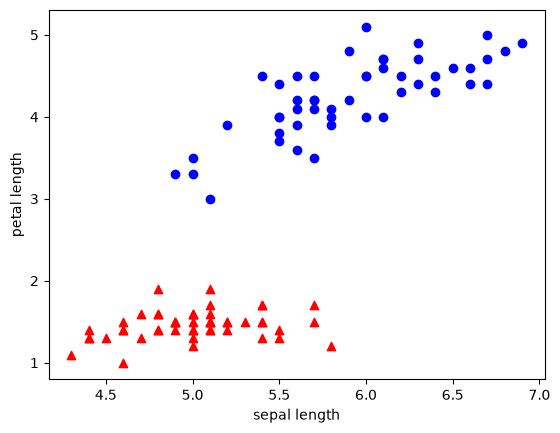

In [6]:
#The diagram of the training data set and it had 1-50 51-100 101-150 different species according
X=df.iloc[:100,[0,2]].values   #training data input
y=df.iloc[:100,[4]]     #trianing data output
plt.scatter(X[0:50,[0]],X[0:50,[1]],marker='^',color="red")
plt.scatter(X[51:100,[0]],X[51:100,[1]],marker='o',color="blue")
plt.xlabel("sepal length")
plt.ylabel("petal length")

In [7]:
ppn.fit(X,y)
ppn.w_
ppn.b_
print("The weights are =",ppn.w_,"bias is =",ppn.b_)

The weights are = [15.31624345  4.19388244] bias is = 3.0


<pre>If we have considered that m2 coeff as x and m1 coeff as y and we can get that bias as b-->c
then we can get a staright line which is our line seprates out lines 
m1,m2=ppn.w_
m1<pre>

In [8]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap
from sklearn.datasets import make_blobs

# 1. Decision Boundary Function with y.ravel() fix
def plot_decision_regions(X, y, classifier, resolution=0.02):
    y = y.ravel()
    markers = ('o', 's', '^', 'v', '<')
    colors = ('red', 'blue', 'lightgreen', 'gray', 'cyan')
    cmap = ListedColormap(colors[:len(np.unique(y))])

    x1_min, x1_max = X[:, 0].min() - 1, X[:, 0].max() + 1
    x2_min, x2_max = X[:, 1].min() - 1, X[:, 1].max() + 1
    xx1, xx2 = np.meshgrid(np.arange(x1_min, x1_max, resolution),
                           np.arange(x2_min, x2_max, resolution))
    
    lab = classifier.predict(np.array([xx1.ravel(), xx2.ravel()]).T)
    lab = lab.reshape(xx1.shape)
    
    # Background colored decision regions
    plt.contourf(xx1, xx2, lab, alpha=0.3, cmap=cmap)
    
    # Explicit black decision boundary line
    plt.contour(xx1, xx2, lab, levels=[0.5], colors='black', linewidths=1.5)
    
    plt.xlim(xx1.min(), xx1.max())
    plt.ylim(xx2.min(), xx2.max())

    for idx, cl in enumerate(np.unique(y)):
        plt.scatter(x=X[y == cl, 0], 
                    y=X[y == cl, 1],
                    alpha=0.8, 
                    c=colors[idx],
                    marker=markers[idx], 
                    label=f'Class {cl}', 
                    edgecolor='black')

# 2. Synthetic Linearly Separable Data
X, y = make_blobs(n_samples=100, centers=2, cluster_std=0.8, random_state=1)

# Standardize features
X_std = X#(X - X.mean(axis=0)) / X.std(axis=0)

# 3. Train Perceptron
ppn = Perceptron(eta=0.1, n_iter=20, random_state=1)
ppn.fit(X_std, y)


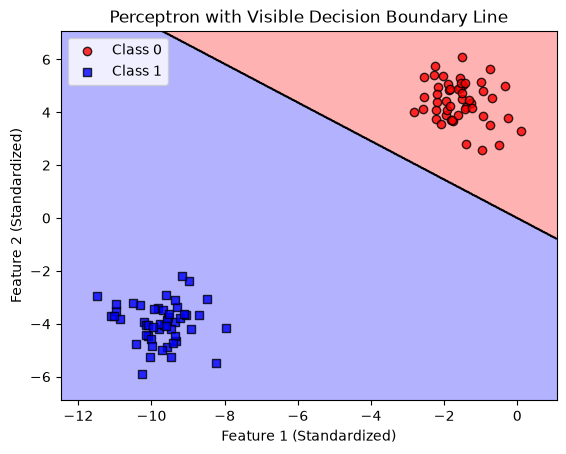

In [9]:
# 4. Plot
plot_decision_regions(X_std, y, classifier=ppn)
plt.xlabel('Feature 1 (Standardized)')
plt.ylabel('Feature 2 (Standardized)')
plt.legend(loc='upper left')
plt.title('Perceptron with Visible Decision Boundary Line')
plt.show()


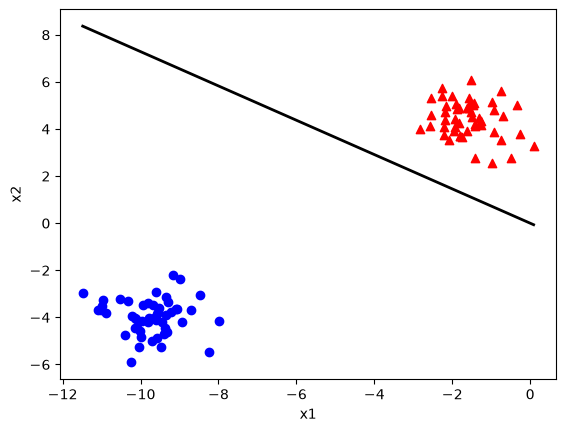

In [10]:
import numpy as np
import matplotlib.pyplot as plt

# Plot training points
plt.scatter(X[y == 0, 0], X[y == 0, 1], color='red',marker='^')
plt.scatter(X[y == 1, 0], X[y == 1, 1], color='blue',marker='o')

# Decision boundary
x1 = np.linspace(X[:, 0].min(), X[:, 0].max(), 100)
x2 = -(ppn.w_[0] * x1 + ppn.b_) / ppn.w_[1]

plt.plot(x1, x2, color='black', linewidth=2)

plt.xlabel("x1")
plt.ylabel("x2")
plt.show()

In [11]:
#now using this skleanrn model of doing this machine learning 
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
model=LinearRegression()
df=pd.read_csv("iris.data.csv")
X=df.iloc[:100,[0,2]]
y=df.iloc[:100,[4]]
x_train,x_test,y_train,y_test=train_test_split(X,y,test_size=0.3)
y=np.where(y=="Iris-setosa",0,1)
model.fit(X,y)


,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False
Name,Type,Value
"coef_ coef_: array of shape (n_features, ) or (n_targets, n_features)Estimated coefficients for the linear regression problem.If multiple targets are passed during the fit (y 2D), thisis a 2D array of shape (n_targets, n_features), while if onlyone target is passed, this is a 1D array of length n_features.","ndarray[float64](1, 2)","[[-0.13, 0.37]]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Defined only when `X`has feature names that are all strings... versionadded:: 1.0","ndarray[object](2,)","['5.1','1.4']"
"intercept_ intercept_: float or array of shape (n_targets,)Independent term in the linear model. Set to 0.0 if`fit_intercept = False`.","ndarray[float64](1,)",[0.11]
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,2
rank_ rank_: intRank of matrix `X`. Only available when `X` is dense.,int64,np.int64(2)


3 boundry classification

In [127]:
X=df.iloc[:,[2,3]]
y=df.iloc[:,[4]]
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
x_train,x_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=1,stratify=y)
scaler=StandardScaler()
scaler.fit(x_train)
x_train=scaler.transform(x_train)
x_test=scaler.transform(x_test)
model=LogisticRegression()
model.fit(x_train,y_train)
y_pred=model.predict(x_test)


/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/sklearn/utils/validation.py:1365: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


In [132]:
np.round(model.predict_proba(x_test[:3]),3)

array([[0.   , 0.091, 0.909],
       [0.967, 0.033, 0.   ],
       [0.252, 0.741, 0.007]])